<a href="https://colab.research.google.com/github/srj1407/Data_Science_and_ML/blob/main/pytorch_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples, noise = 0.03, random_state = 42)

In [2]:
print(X[:5])
print(y[:5])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
[1 1 1 1 0]


In [3]:
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0], "X2": X[:, 1], "label": y})
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [4]:
circles['label'].value_counts()

,count
label,
1,500
0,500


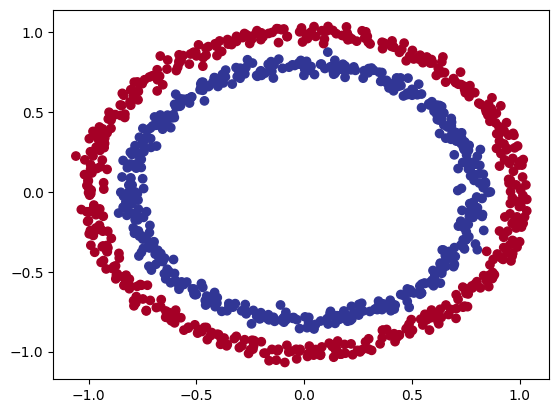

In [5]:
from matplotlib import pyplot as plt

plt.scatter(x = X[:, 0], y = X[:, 1], c = y, cmap = plt.cm.RdYlBu)

In [6]:
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
type(X), type(y), X.dtype

(numpy.ndarray, numpy.ndarray, dtype('float64'))

In [8]:
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X.shape, y.shape, X.dtype, y.dtype, type(X), type(y)

(torch.Size([1000, 2]),
 torch.Size([1000]),
 torch.float32,
 torch.float32,
 torch.Tensor,
 torch.Tensor)

In [9]:
X[:10], y[:10]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967],
         [-0.4796,  0.6764],
         [-0.0136,  0.8033],
         [ 0.7715,  0.1478],
         [-0.1693, -0.7935],
         [-0.1215,  1.0215]]),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train , y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [11]:
from torch import nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [12]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

In [13]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer_1 = nn.Linear(in_features = 2, out_features = 5)
    self.linear_layer_2 = nn.Linear(in_features = 5, out_features = 1)

  def forward(self, x):
    return self.linear_layer_2(self.linear_layer_1(x))

model_0 = CircleModelV0().to(device)
next(model_0.parameters()).device

device(type='cpu')

In [14]:
model_0

CircleModelV0(
  (linear_layer_1): Linear(in_features=2, out_features=5, bias=True)
  (linear_layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [15]:
model_0 = nn.Sequential(
    nn.Linear(in_features = 2, out_features = 5),
    nn.Linear(in_features = 5, out_features = 1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [16]:
model_0.eval()
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
untrained_preds[:10]

tensor([[-1.0668],
        [-1.2133],
        [-0.5907],
        [-1.2021],
        [-0.4444],
        [-0.5349],
        [-1.0633],
        [-0.9041],
        [-0.5975],
        [-1.2215]])

In [17]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.1)

In [18]:
def accuracy(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [19]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 1000

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(EPOCHS):
  model_0.train()
  train_pred_logits = model_0(X_train).squeeze()
  train_pred_prob = train_pred_logits.sigmoid()
  train_pred_labels = torch.round(train_pred_prob)
  train_loss = loss_fn(train_pred_logits, y_train)
  train_acc = accuracy(y_train, train_pred_labels)
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()
  model_0.eval()
  with torch.inference_mode():
    test_pred_logits = model_0(X_test).squeeze()
    test_pred_prob = test_pred_logits.sigmoid()
    test_pred_labels = torch.round(test_pred_prob)
    test_loss = loss_fn(test_pred_logits, y_test)
    test_acc = accuracy(y_test, test_pred_labels)
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Train Loss: {train_loss} | Train Accuracy: {train_acc} | Test Loss: {test_loss} | Test Accuracy: {test_acc}")

Epoch: 0 | Train Loss: 0.775959312915802 | Train Accuracy: 50.0 | Test Loss: 0.7608146667480469 | Test Accuracy: 50.0
Epoch: 10 | Train Loss: 0.7194401025772095 | Train Accuracy: 50.0 | Test Loss: 0.7110934257507324 | Test Accuracy: 50.0
Epoch: 20 | Train Loss: 0.7024264335632324 | Train Accuracy: 47.5 | Test Loss: 0.6969556212425232 | Test Accuracy: 48.5
Epoch: 30 | Train Loss: 0.6969237327575684 | Train Accuracy: 44.875 | Test Loss: 0.6929908990859985 | Test Accuracy: 49.0
Epoch: 40 | Train Loss: 0.695010244846344 | Train Accuracy: 47.5 | Test Loss: 0.6920332312583923 | Test Accuracy: 50.5
Epoch: 50 | Train Loss: 0.694266676902771 | Train Accuracy: 48.625 | Test Loss: 0.6919477581977844 | Test Accuracy: 50.0
Epoch: 60 | Train Loss: 0.6939224004745483 | Train Accuracy: 49.125 | Test Loss: 0.6920921802520752 | Test Accuracy: 51.5
Epoch: 70 | Train Loss: 0.6937251091003418 | Train Accuracy: 49.5 | Test Loss: 0.6922795176506042 | Test Accuracy: 51.5
Epoch: 80 | Train Loss: 0.693589806556

In [20]:
import requests
from pathlib import Path

if Path('helper_functions.py').is_file():
  print('helper_functions.py already exists')
else:
  print('Downloading helper_functions.py')
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open('helper_functions.py', 'wb') as f:
    f.write(request.content)

In [21]:
from helper_functions import plot_predictions, plot_decision_boundary

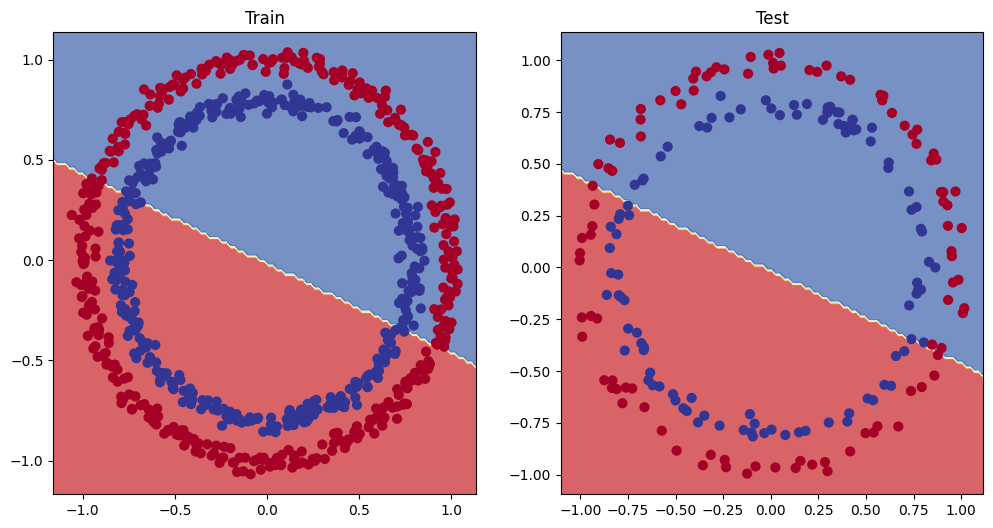

In [22]:
plt.figure(figsize = (12, 6))

plt.subplot(1, 2, 1)
plt.title('Train')
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title('Test')
plot_decision_boundary(model_0, X_test, y_test)

In [23]:
X_train[:10], y_train[:10]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994],
         [-0.8837, -0.4678],
         [-0.3836,  0.6987],
         [ 0.6047,  0.5163],
         [-0.5869,  0.7804],
         [ 0.8833, -0.5178]]),
 tensor([1., 0., 0., 0., 1., 0., 1., 1., 0., 0.]))

In [24]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)

  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [25]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.1)

In [26]:
X_train.shape

torch.Size([800, 2])

In [27]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  y_train_logits = model_1(X_train).squeeze()
  y_train_prob = y_train_logits.sigmoid()
  y_train_labels = torch.round(y_train_prob)

  train_loss = loss_fn(y_train_logits, y_train)
  train_acc = accuracy(y_train, y_train_labels)

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    y_test_logits = model_1(X_test).squeeze()
    y_test_prob = y_test_logits.sigmoid()
    y_test_labels = torch.round(y_test_prob)
    test_loss = loss_fn(y_test_logits, y_test)
    test_acc = accuracy(y_test, y_test_labels)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Train Loss: {train_loss} | Train Accuracy: {train_acc} | Test Loss: {test_loss} | Test Accuracy: {test_acc}")

Epoch: 0 | Train Loss: 0.6939550638198853 | Train Accuracy: 50.875 | Test Loss: 0.6926146149635315 | Test Accuracy: 51.0
Epoch: 10 | Train Loss: 0.6936882138252258 | Train Accuracy: 50.24999999999999 | Test Loss: 0.6927037239074707 | Test Accuracy: 50.0
Epoch: 20 | Train Loss: 0.6935124397277832 | Train Accuracy: 50.125 | Test Loss: 0.6928302049636841 | Test Accuracy: 49.5
Epoch: 30 | Train Loss: 0.6933860778808594 | Train Accuracy: 50.5 | Test Loss: 0.6929664015769958 | Test Accuracy: 48.0
Epoch: 40 | Train Loss: 0.6932918429374695 | Train Accuracy: 50.375 | Test Loss: 0.693103015422821 | Test Accuracy: 49.0
Epoch: 50 | Train Loss: 0.6932203769683838 | Train Accuracy: 49.875 | Test Loss: 0.6932356953620911 | Test Accuracy: 50.0
Epoch: 60 | Train Loss: 0.6931658983230591 | Train Accuracy: 49.375 | Test Loss: 0.693362295627594 | Test Accuracy: 51.5
Epoch: 70 | Train Loss: 0.693123996257782 | Train Accuracy: 49.375 | Test Loss: 0.6934813857078552 | Test Accuracy: 50.5
Epoch: 80 | Train L

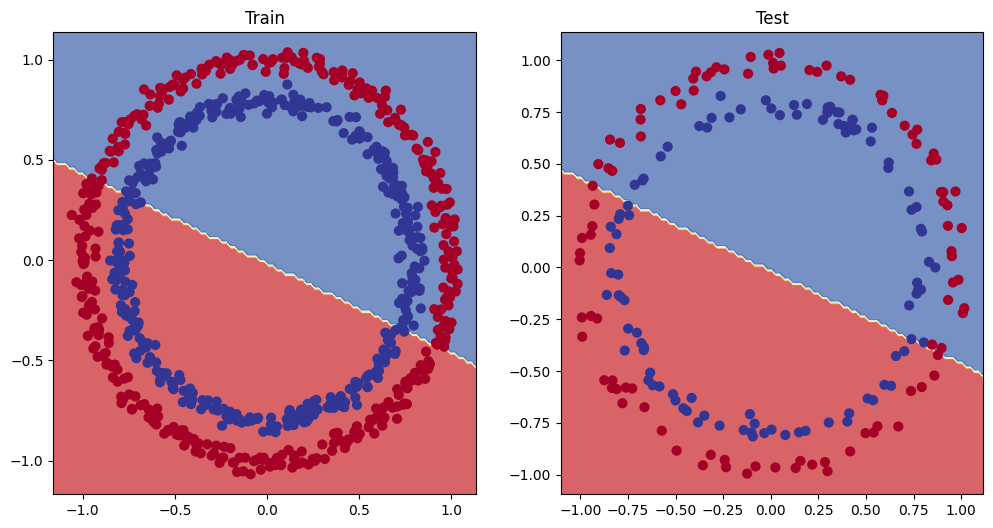

In [28]:
plt.figure(figsize = (12, 6))

plt.subplot(1, 2, 1)
plt.title('Train')
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title('Test')
plot_decision_boundary(model_1, X_test, y_test)

In [29]:
weight  = 0.5
bias = 0.3
start = 0
end = 1
step = 0.01
X = torch.arange(start, end, step).unsqueeze(dim = 1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.3000],
         [0.3050],
         [0.3100],
         [0.3150],
         [0.3200],
         [0.3250],
         [0.3300],
         [0.3350],
         [0.3400],
         [0.3450]]))

In [30]:
y.shape

torch.Size([100, 1])

In [31]:
X.shape

torch.Size([100, 1])

In [32]:
train_split = int(0.8 * len(X))

X_train_reg, y_train_reg = X[:train_split], y[:train_split]
X_test_reg, y_test_reg = X[train_split:], y[train_split:]

print(len(X_train_reg))
print(len(y_train_reg))
print(len(X_test_reg))
print(len(y_test_reg))

80
80
20
20


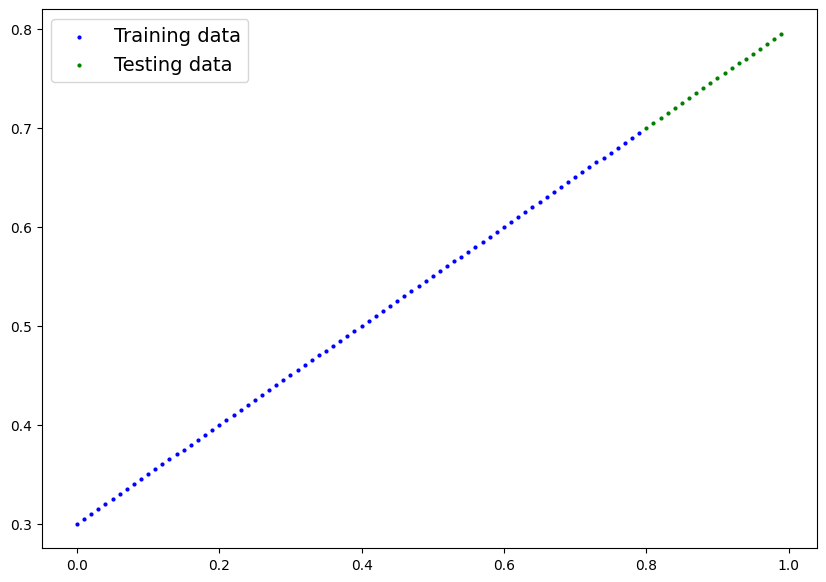

In [33]:
plot_predictions(train_data=X_train_reg,
    train_labels=y_train_reg,
    test_data=X_test_reg,
    test_labels=y_test_reg
);

In [34]:
model_2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features = 10),
    nn.Linear(in_features  = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)
).to(device)

In [35]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_2.parameters(), lr = 0.1)

In [36]:
X_train_reg.shape

torch.Size([80, 1])

In [37]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train_reg, y_train_reg = X_train_reg.to(device), y_train_reg.to(device)
X_test_reg, y_test_reg = X_test_reg.to(device), y_test_reg.to(device)

for epoch in range(epochs):
  model_2.train()

  y_train_pred_reg = model_2(X_train_reg)
  train_loss = loss_fn(y_train_pred_reg, y_train_reg)

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    y_test_pred_reg = model_2(X_test_reg)
    test_loss = loss_fn(y_test_pred_reg, y_test_reg)

  if epoch % 10 == 0:
    print(f'Epoch: {epoch} | Train Loss: {train_loss} | Test Loss: {test_loss}')

Epoch: 0 | Train Loss: 0.6808584928512573 | Test Loss: 0.3624277710914612
Epoch: 10 | Train Loss: 0.08394233882427216 | Test Loss: 0.18580684065818787
Epoch: 20 | Train Loss: 0.12057546526193619 | Test Loss: 0.029988666996359825
Epoch: 30 | Train Loss: 0.10047624260187149 | Test Loss: 0.008452233858406544
Epoch: 40 | Train Loss: 0.0842452421784401 | Test Loss: 0.016062363982200623
Epoch: 50 | Train Loss: 0.07816897332668304 | Test Loss: 0.02506525255739689
Epoch: 60 | Train Loss: 0.07387486100196838 | Test Loss: 0.007104992866516113
Epoch: 70 | Train Loss: 0.07525168359279633 | Test Loss: 0.014595940709114075
Epoch: 80 | Train Loss: 0.07560782879590988 | Test Loss: 0.03043798729777336
Epoch: 90 | Train Loss: 0.05791439861059189 | Test Loss: 0.02263776585459709
Epoch: 100 | Train Loss: 0.06352441757917404 | Test Loss: 0.007315832190215588
Epoch: 110 | Train Loss: 0.07145558297634125 | Test Loss: 0.022315338253974915
Epoch: 120 | Train Loss: 0.05364008992910385 | Test Loss: 0.00608792901

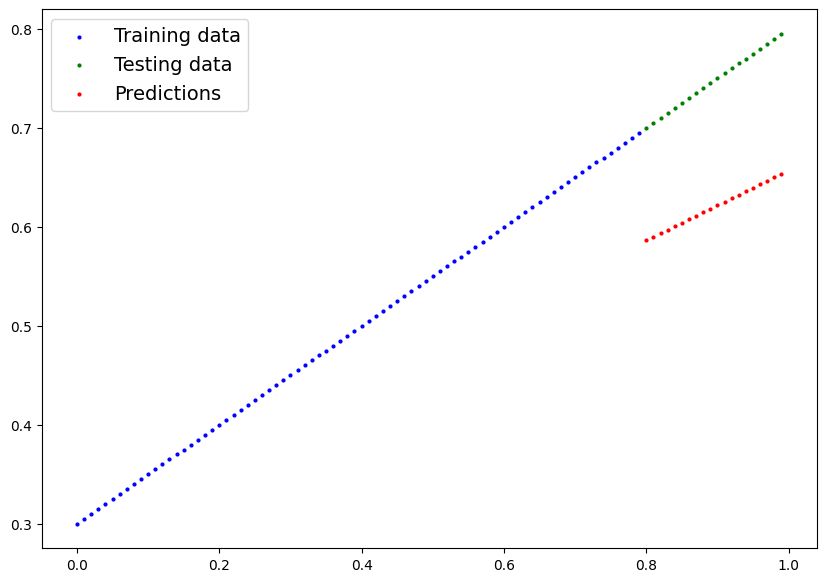

In [38]:
model_2.eval()
with torch.inference_mode():
  y_preds_test_reg = model_2(X_test_reg)

plot_predictions(train_data=X_train_reg.cpu(),
                 train_labels=y_train_reg.cpu(),
                 test_data=X_test_reg.cpu(),
                 test_labels=y_test_reg.cpu(),
                 predictions=y_preds_test_reg.cpu());

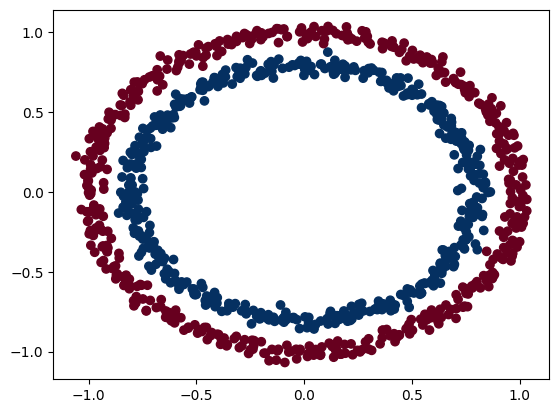

In [39]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

X, y = make_circles(n_samples = 1000, noise = 0.03, random_state = 42)

plt.scatter(X[:, 0], X[:, 1], c = y, cmap = plt.cm.RdBu)

In [40]:
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [41]:
from torch import nn

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
    self.relu = nn.ReLU()

  def forward(self, X):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(X)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [42]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_3.parameters(), lr = 0.2)

In [43]:
X_train.shape, type(X_train)

(torch.Size([800, 2]), torch.Tensor)

In [44]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_3.train()

  y_train_logits = model_3(X_train).squeeze()
  y_train_preds = y_train_logits.sigmoid()
  y_train_labels = y_train_preds.round()

  train_loss = loss_fn(y_train_logits, y_train)
  train_acc = accuracy(y_train, y_train_labels)

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    y_test_logits = model_3(X_test).squeeze()
    y_test_preds = y_test_logits.sigmoid()
    y_test_labels = y_test_preds.round()

    test_loss = loss_fn(y_test_logits, y_test)
    test_acc = accuracy(y_test, y_test_labels)

  if epoch % 10 == 0:
    print(f'Epoch: {epoch} | Train Loss: {train_loss} | Train Accuracy; {train_acc} | Test Loss: {test_loss} | Test Accuracy: {test_acc}')

Epoch: 0 | Train Loss: 0.6929463148117065 | Train Accuracy; 50.0 | Test Loss: 0.6931237578392029 | Test Accuracy: 50.0
Epoch: 10 | Train Loss: 0.6922427415847778 | Train Accuracy; 59.0 | Test Loss: 0.6922877430915833 | Test Accuracy: 57.99999999999999
Epoch: 20 | Train Loss: 0.6919456720352173 | Train Accuracy; 67.375 | Test Loss: 0.6919259428977966 | Test Accuracy: 70.5
Epoch: 30 | Train Loss: 0.6916732788085938 | Train Accuracy; 54.0 | Test Loss: 0.6915935277938843 | Test Accuracy: 54.50000000000001
Epoch: 40 | Train Loss: 0.6914112567901611 | Train Accuracy; 52.75 | Test Loss: 0.6912994980812073 | Test Accuracy: 52.5
Epoch: 50 | Train Loss: 0.69115149974823 | Train Accuracy; 52.87500000000001 | Test Loss: 0.6910086274147034 | Test Accuracy: 53.0
Epoch: 60 | Train Loss: 0.6908984184265137 | Train Accuracy; 53.125 | Test Loss: 0.6907215118408203 | Test Accuracy: 54.0
Epoch: 70 | Train Loss: 0.6906354427337646 | Train Accuracy; 53.0 | Test Loss: 0.6904102563858032 | Test Accuracy: 55.0

In [45]:
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

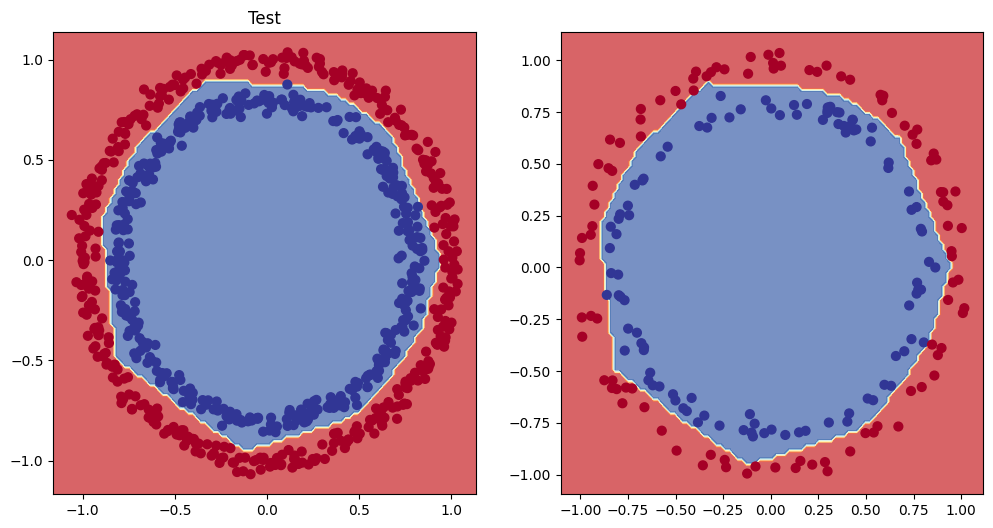

In [46]:
plt.figure(figsize = (12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)

plt.title("Test")
plt.subplot(1, 2, 2)
plot_decision_boundary(model_3, X_test, y_test)

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]]) tensor([1., 1., 1., 1., 0.])


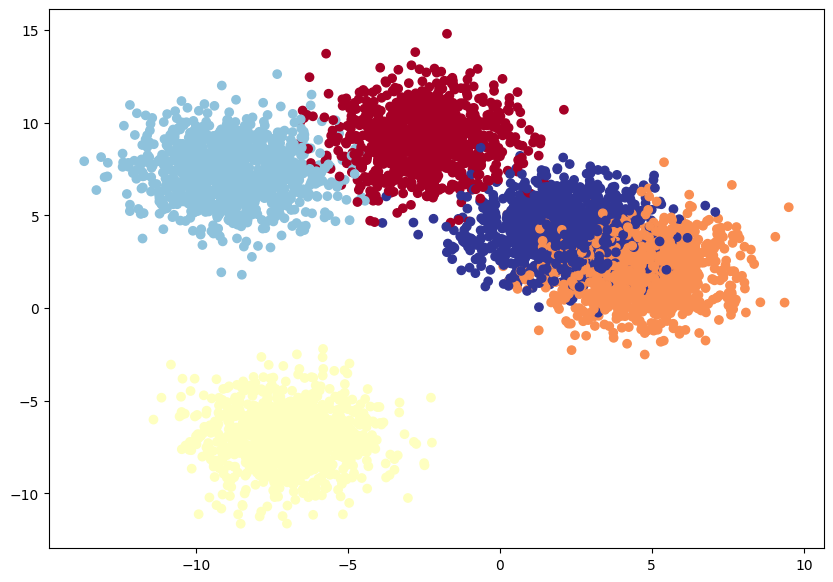

In [72]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES = 5
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(
    n_samples = 5000,
    centers = NUM_CLASSES,
    n_features = NUM_FEATURES,
    cluster_std = 1.5,
    random_state = RANDOM_SEED
)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)
print(X[:5], y[:5])

X_train_blob, X_test_blob, y_train_blob, y_test_blob = train_test_split(X_blob, y_blob, test_size = 0.2, random_state = RANDOM_SEED)

plt.figure(figsize = (10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c = y_blob, cmap = plt.cm.RdYlBu)

In [73]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [74]:
from torch import nn

class BlobModel(nn.Module):
  def __init__(self, in_features, out_features, hidden_features = 8):
    super().__init__()
    self.linear_layer = nn.Sequential(
        nn.Linear(in_features = in_features, out_features = hidden_features),
        nn.Linear(in_features = hidden_features, out_features = hidden_features),
        nn.Linear(in_features = hidden_features, out_features = out_features)
    )

  def forward(self, X):
    return self.linear_layer(X)

model_4 = BlobModel(NUM_FEATURES, NUM_CLASSES, 8).to(device)
model_4

BlobModel(
  (linear_layer): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=5, bias=True)
  )
)

In [75]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_4.parameters(), lr = 0.1)

In [76]:
model_4.eval()
with torch.inference_mode():
  res = model_4(X_train_blob.to(device))[:5]

res.softmax(dim = 1)

tensor([[0.3260, 0.1198, 0.1234, 0.3035, 0.1274],
        [0.3136, 0.1084, 0.1545, 0.2591, 0.1644],
        [0.3425, 0.1105, 0.1109, 0.3245, 0.1116],
        [0.3366, 0.1086, 0.1241, 0.3037, 0.1269],
        [0.3350, 0.1278, 0.0874, 0.3634, 0.0863]])

In [77]:
res.shape

torch.Size([5, 5])

In [78]:
y_train_blob[:5]

tensor([1, 1, 1, 1, 1])

In [79]:
epochs = 1000

X_train_blob, y_train_blob = X_train_blob.to(device), y_train_blob.to(device)
X_test_blob, y_test_blob = X_test_blob.to(device), y_test_blob.to(device)

model_4.train()

for epoch in range(epochs):
  y_train_logits = model_4(X_train_blob)
  y_train_preds = y_train_logits.softmax(dim = 1).argmax(dim = 1)
  train_loss = loss_fn(y_train_logits, y_train_blob)
  train_acc = accuracy(y_train_blob, y_train_preds)

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  model_4.eval()
  with torch.inference_mode():
    y_test_logits = model_4(X_test_blob)
    y_test_preds = y_test_logits.softmax(dim = 1).argmax(dim = 1)
    test_loss = loss_fn(y_test_logits, y_test_blob)
    test_acc = accuracy(y_test_blob, y_test_preds)

  if epoch % 10 == 0:
    print(f'Epoch: {epoch} | Train Loss: {train_loss} | Train Accuracy: {train_acc} | Test Loss: {test_loss} | Test Accuracy: {test_acc}')


Epoch: 0 | Train Loss: 2.270195484161377 | Train Accuracy: 8.15 | Test Loss: 1.2294495105743408 | Test Accuracy: 25.5
Epoch: 10 | Train Loss: 1.018093466758728 | Train Accuracy: 43.05 | Test Loss: 1.0161051750183105 | Test Accuracy: 65.2
Epoch: 20 | Train Loss: 0.4366976022720337 | Train Accuracy: 86.775 | Test Loss: 0.4013982117176056 | Test Accuracy: 91.7
Epoch: 30 | Train Loss: 0.31861332058906555 | Train Accuracy: 91.0 | Test Loss: 0.2958837151527405 | Test Accuracy: 91.9
Epoch: 40 | Train Loss: 0.2691260278224945 | Train Accuracy: 91.45 | Test Loss: 0.2517494261264801 | Test Accuracy: 92.10000000000001
Epoch: 50 | Train Loss: 0.24503014981746674 | Train Accuracy: 91.5 | Test Loss: 0.2299680858850479 | Test Accuracy: 92.2
Epoch: 60 | Train Loss: 0.23179146647453308 | Train Accuracy: 91.57499999999999 | Test Loss: 0.21789665520191193 | Test Accuracy: 92.10000000000001
Epoch: 70 | Train Loss: 0.2237810641527176 | Train Accuracy: 91.57499999999999 | Test Loss: 0.2105441689491272 | Tes

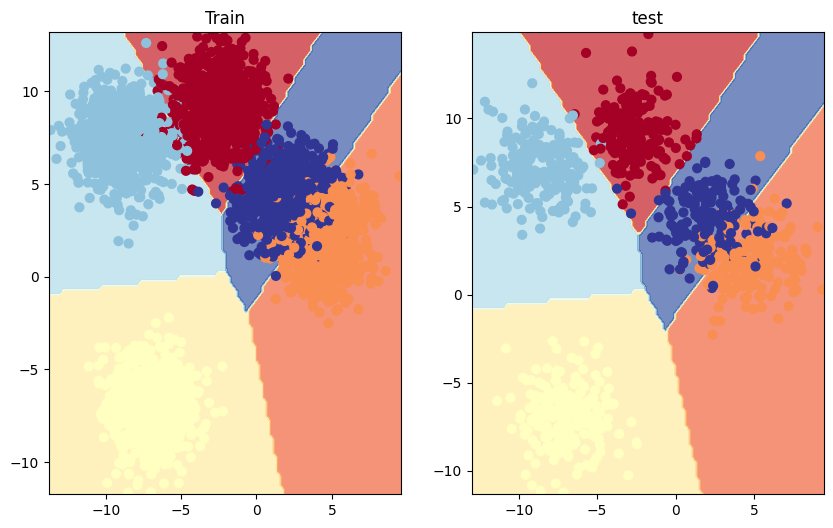

In [80]:
  plt.figure(figsize = (10, 6))
  plt.subplot(1, 2, 1)
  plt.title('Train')
  plot_decision_boundary(model_4, X_train_blob, y_train_blob)
  plt.subplot(1, 2, 2)
  plt.title('test')
  plot_decision_boundary(model_4, X_test_blob, y_test_blob)

In [82]:
try:
  from torchmetrics import Accuracy
except:
  !pip install torchmetrics
  from torchmetrics import Accuracy

torchmetrics_accuracy = Accuracy(task = 'multiclass', num_classes = 5).to(device)
torchmetrics_accuracy(y_test_preds, y_test_blob)

tensor(0.9450)